In [1]:
from typing_extensions import TypedDict, List, Dict
from typing import Optional
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage,AIMessage
from langgraph.graph import StateGraph, START, END

In [2]:
# 1. Define state structure
class State(TypedDict):
    messages: List[Dict[str, str]]


In [3]:
# 2. Set up Gemini LLM
model_id= "gemini-2.0-flash-lite-001"
llm = init_chat_model(model=model_id,model_provider="google_vertexai", project="glassy-keyword-461110-r8")


In [4]:
# 3. Define LLM-based node
def bot_node(state: State) -> State:
    print("🤖 Calling LLM with:", state["messages"][-1]["content"])
    user_msg = state["messages"][-1]["content"]

    response = llm([HumanMessage(content=user_msg)]).content
    state["messages"].append({"role": "assistant", "content": response})
    return state

In [5]:
# 4. Build the graph
builder = StateGraph(State)
builder.add_node("bot_node", bot_node)
builder.set_entry_point("bot_node")

In [6]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore



In [7]:
# 5. Compile with in-memory checkpointing
checkpointer = MemorySaver()
store = InMemoryStore()
graph = builder.compile(checkpointer=checkpointer, store=store)


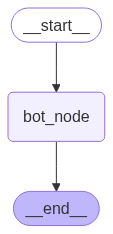

In [8]:
from utils import draw_graph
draw_graph(graph)

In [9]:
# 6. Input message
initial_state = {
    "messages": [{"role": "user", "content": "What is LangGraph used for?"}]
}

In [10]:
# === RUN WITH .invoke() ===
print("\n🚀 Running with `.invoke()`:\n")
final_state = graph.invoke(initial_state,config={"configurable": {"thread_id": "run1"}})
print("✅ Final result:", final_state)


🚀 Running with `.invoke()`:

🤖 Calling LLM with: What is LangGraph used for?


C:\Users\bhargav#\AppData\Local\Temp\ipykernel_16940\1140307399.py:6: LangChainDeprecationWarning: The method `BaseChatModel.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  response = llm([HumanMessage(content=user_msg)]).content


✅ Final result: {'messages': [{'role': 'user', 'content': 'What is LangGraph used for?'}, {'role': 'assistant', 'content': 'LangGraph is a framework built on top of LangChain, designed to help developers build **complex, stateful, and dynamic LLM-powered applications** with multiple interacting agents. It essentially provides a way to orchestrate a "graph" of LLMs, tools, and other components, enabling them to interact and cooperate in a more structured and sophisticated manner than basic sequential chains.\n\nHere\'s a breakdown of what LangGraph is used for and why it\'s beneficial:\n\n**Key Uses and Benefits:**\n\n*   **Complex Agent Workflows:**  LangGraph excels at building applications where multiple LLMs or agents need to collaborate to achieve a common goal. This includes scenarios like:\n    *   **Multi-agent collaboration:**  Where different agents specialize in different tasks (e.g., research, summarization, editing, coding) and communicate with each other to complete a larg

In [11]:
# === RUN WITH .stream() ===
print("\n🔄 Running with `.stream()`:\n")
for step in graph.stream(initial_state,config={"configurable": {"thread_id": "run1"}}):
    if "node" in step:
        print(f"🧩 Step: {step['node']}")
        print(f"📥 State so far: {step['state']}\n")
    elif "final" in step:
        print("🏁 Final output:")
        print(step["final"])


🔄 Running with `.stream()`:

🤖 Calling LLM with: LangGraph is a framework built on top of LangChain, designed to help developers build **complex, stateful, and dynamic LLM-powered applications** with multiple interacting agents. It essentially provides a way to orchestrate a "graph" of LLMs, tools, and other components, enabling them to interact and cooperate in a more structured and sophisticated manner than basic sequential chains.

Here's a breakdown of what LangGraph is used for and why it's beneficial:

**Key Uses and Benefits:**

*   **Complex Agent Workflows:**  LangGraph excels at building applications where multiple LLMs or agents need to collaborate to achieve a common goal. This includes scenarios like:
    *   **Multi-agent collaboration:**  Where different agents specialize in different tasks (e.g., research, summarization, editing, coding) and communicate with each other to complete a larger project.
    *   **Iterative processes:** Applications that involve multiple rou

In [12]:
import asyncio

async def run_async():
    print("\n⚡ Running with `.astream()`:\n")
    async for step in graph.astream(initial_state, config={"configurable": {"thread_id": "async-1"}}):
        if "node" in step:
            print(f"🧩 Node: {step['node']}")
            print(f"📥 State: {step['state']}\n")
        elif "final" in step:
            print("✅ Final Output:", step["final"])



In [13]:
asyncio.run(run_async())


RuntimeError: asyncio.run() cannot be called from a running event loop